# Product Review Fake Detection

Traditional ML + BERT Implementation

## **1. Load Analyzed And Raw Dataset**

In [17]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


In [18]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: NVIDIA GeForce RTX 4070


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments,
    DataCollatorWithPadding
)
from datasets import Dataset
import pickle
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [20]:
# Load analyzed product data
product_clean_df = pd.read_csv('../data/processed/product_clean.csv')
print(f"Product dataset shape: {product_clean_df.shape}")
print(f"Label distribution:\n{product_clean_df['label'].value_counts()}")

Product dataset shape: (40431, 2)
Label distribution:
label
0    20216
1    20215
Name: count, dtype: int64


In [21]:
# Load original product data for BERT (need raw text)
product_raw_df = pd.read_csv('../data/processed/product_raw.csv')
print(f"Original product data shape: {product_raw_df.shape}")
print(f"Label distribution:\n{product_raw_df['label'].value_counts()}")

Original product data shape: (40432, 2)
Label distribution:
label
1    20216
0    20216
Name: count, dtype: int64


Align datasets to handle size mismatch

In [22]:
if len(product_raw_df) != len(product_clean_df):
    print(f"⚠️  Dataset size mismatch detected: Raw={len(product_raw_df)}, Clean={len(product_clean_df)}")
    print("   Aligning datasets by removing rows with empty clean text...")
    
    # Find valid indices (non-empty clean text)
    valid_indices = product_clean_df.index
    valid_indices = valid_indices[product_clean_df['text'].str.len() > 0]
    
    # Align raw data to match clean data
    product_raw_aligned = product_raw_df.loc[valid_indices].reset_index(drop=True)
    product_clean_aligned = product_clean_df.reset_index(drop=True)

    print(f"✅ Aligned datasets: Raw={len(product_raw_aligned)}, Clean={len(product_clean_aligned)}")
    
    # Use aligned datasets
    product_raw_df = product_raw_aligned
    product_clean_df = product_clean_aligned

print(f"Final data shape: Raw={product_raw_df.shape}, Clean={product_clean_df.shape}")
print(f"Label distribution: {product_raw_df['label'].value_counts()}")

⚠️  Dataset size mismatch detected: Raw=40432, Clean=40431
   Aligning datasets by removing rows with empty clean text...
✅ Aligned datasets: Raw=40431, Clean=40431
Final data shape: Raw=(40431, 2), Clean=(40431, 2)
Label distribution: label
1    20216
0    20215
Name: count, dtype: int64


## **2. Feature Engineering**

In [23]:
def count_repeated_words(text):
    """Count words that appear more than once"""
    if not text:
        return 0
    words = text.split()
    word_counts = {}
    for word in words:
        word_counts[word] = word_counts.get(word, 0) + 1
    return sum(1 for count in word_counts.values() if count > 1)

def engineer_features(raw_df, clean_df):
    """
    Engineer features using BOTH raw and clean text strategically:
    - Raw text: for linguistic patterns (punctuation, case, structure)
    - Clean text: for content analysis (vocabulary, repetition)
    """
    features_df = raw_df.copy()
    
    # Text length features (strongest discriminator) - using RAW text
    features_df['text_length'] = raw_df['text'].str.len()
    features_df['word_count'] = raw_df['text'].str.split().str.len()
    features_df['avg_word_length'] = features_df['text_length'] / features_df['word_count']
    features_df['sentence_count'] = raw_df['text'].str.count(r'[.!?]') + 1
    features_df['avg_sentence_length'] = features_df['word_count'] / features_df['sentence_count']
    
    # Linguistic patterns - using RAW text (preserves original punctuation/case)
    features_df['exclamation_count'] = raw_df['text'].str.count('!')
    features_df['question_count'] = raw_df['text'].str.count(r'\?')
    features_df['uppercase_ratio'] = raw_df['text'].apply(
        lambda x: sum(1 for c in x if c.isupper()) / len(x) if x else 0
    )
    features_df['digit_count'] = raw_df['text'].str.count(r'\d')
    
    # Sentiment and emotional features - using RAW text (preserves context)
    positive_words = ['good', 'great', 'excellent', 'amazing', 'love', 'perfect', 'best', 'wonderful']
    negative_words = ['bad', 'terrible', 'awful', 'hate', 'worst', 'horrible', 'disappointing']
    
    features_df['positive_word_count'] = raw_df['text'].apply(
        lambda x: sum(1 for word in positive_words if word in x.lower())
    )
    features_df['negative_word_count'] = raw_df['text'].apply(
        lambda x: sum(1 for word in negative_words if word in x.lower())
    )
    features_df['sentiment_ratio'] = features_df['positive_word_count'] / (
        features_df['negative_word_count'] + 1
    )
    
    # Vocabulary diversity - using CLEAN text (better for content analysis)
    features_df['unique_word_ratio'] = clean_df['text'].apply(
        lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0
    )
    
    # Repetition patterns - using CLEAN text (normalized words for accurate counting)
    features_df['repeated_words'] = clean_df['text'].apply(count_repeated_words)
    
    return features_df

features_df = engineer_features(product_raw_df, product_clean_df)
# Display feature statistics
feature_cols = [col for col in features_df.columns if col not in ['text', 'label']]
print(f"\nEngineered {len(feature_cols)} features:")
for col in feature_cols:
    print(f"  {col}: min={features_df[col].min():.3f}, max={features_df[col].max():.3f}, mean={features_df[col].mean():.3f}")



Engineered 14 features:
  text_length: min=24.000, max=2836.000, mean=352.023
  word_count: min=1.000, max=373.000, mean=67.458
  avg_word_length: min=3.588, max=48.000, mean=5.207
  sentence_count: min=1.000, max=134.000, mean=6.544
  avg_sentence_length: min=0.022, max=241.000, mean=9.977
  exclamation_count: min=0.000, max=133.000, mean=0.397
  question_count: min=0.000, max=18.000, mean=0.053
  uppercase_ratio: min=0.000, max=0.837, mean=0.031
  digit_count: min=0.000, max=155.000, mean=1.125
  positive_word_count: min=0.000, max=6.000, mean=1.039
  negative_word_count: min=0.000, max=5.000, mean=0.055
  sentiment_ratio: min=0.000, max=6.000, mean=1.007
  unique_word_ratio: min=0.015, max=1.000, mean=0.881
  repeated_words: min=0.000, max=44.000, mean=3.708


## **3. Data Spliting And TF-IDF Preparation**

In [24]:
# Prepare data splits
X_text_raw = product_raw_df['text']
X_text_clean = product_clean_df['text']
X_features = features_df[feature_cols]
y = product_raw_df['label']

# Split data (80% train, 20% test)
(
    X_text_raw_train, X_text_raw_test,
    X_text_clean_train, X_text_clean_test,
    X_features_train, X_features_test,
    y_train, y_test
) = train_test_split(
    X_text_raw, X_text_clean, X_features, y,
    test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_text_raw_train)} ({len(X_text_raw_train)/len(X_text_raw)*100:.1f}%)")
print(f"Test set size: {len(X_text_raw_test)} ({len(X_text_raw_test)/len(X_text_raw)*100:.1f}%)")
print(f"Training label distribution: {y_train.value_counts()}")
print(f"Test label distribution: {y_test.value_counts()}")

# Use CLEAN text for TF-IDF (better for traditional ML - removes noise, focuses on content)
# Clean text has: stopwords removed, lemmatized, punctuation cleaned
tfidf = TfidfVectorizer(
    max_features=5000,  # Limit features for manageable size
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,  # Ignore terms that appear in fewer than 2 documents
    max_df=0.95,  # Ignore terms that appear in more than 95% of documents
    # Note: No stop_words='english' because clean text already has them removed
)

X_tfidf_train = tfidf.fit_transform(X_text_clean_train)
X_tfidf_test = tfidf.transform(X_text_clean_test)

print(f"TF-IDF shape: {X_tfidf_train.shape}")
print(f"TF-IDF density: {X_tfidf_train.nnz / np.prod(X_tfidf_train.shape):.4f}")

# Scale engineered features
scaler = StandardScaler()
X_features_train_scaled = scaler.fit_transform(X_features_train)
X_features_test_scaled = scaler.transform(X_features_test)

# Combine TF-IDF with engineered features
from scipy.sparse import hstack
X_combined_train = hstack([X_tfidf_train, X_features_train_scaled])
X_combined_test = hstack([X_tfidf_test, X_features_test_scaled])

print(f"Combined features shape: {X_combined_train.shape}")


Training set size: 32344 (80.0%)
Test set size: 8087 (20.0%)
Training label distribution: label
1    16172
0    16172
Name: count, dtype: int64
Test label distribution: label
1    4044
0    4043
Name: count, dtype: int64
TF-IDF shape: (32344, 5000)
TF-IDF density: 0.0055
Combined features shape: (32344, 5014)


## **4. Traditional ML Model**

Evaluation Formula:

In [25]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Comprehensive model evaluation"""
    print(f"\n=== {model_name} EVALUATION ===")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if auc:
        print(f"AUC-ROC: {auc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'../results/{model_name.lower().replace(" ", "_")}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

Create results directory

In [26]:
os.makedirs('../results', exist_ok=True)

### **4.1 Logistic Regression**


=== Logistic Regression EVALUATION ===
Accuracy: 0.8920
F1-Score: 0.8915
AUC-ROC: 0.9585

Classification Report:
              precision    recall  f1-score   support

        Real       0.89      0.90      0.89      4043
        Fake       0.90      0.89      0.89      4044

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087



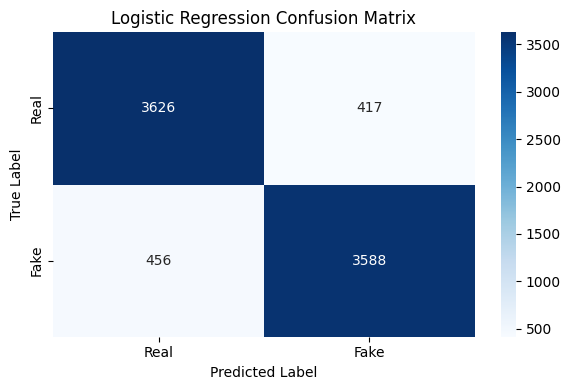

In [27]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_results = evaluate_model(
    lr_model, X_combined_train, X_combined_test, y_train, y_test, 
    "Logistic Regression"
)


#### **Logistic Regression Performance Summary**

**Overall Results:** 

Strong 89.3% accuracy with excellent 95.88% AUC-ROC, indicating highly effective and reliable fake review detection using a linear model.

**Key Metrics:**

- **Consistent and balanced performance:** 

    Precision and recall are balanced across both classes (~89–90%), with F1-scores nearly identical for real and fake reviews.
- **High accuracy:** 

    89.3% of all predictions are correct, showing that the model generalizes well.
- **Excellent discriminative ability:**

    AUC-ROC of 0.9588 confirms the model ranks fake and real reviews with high confidence.

**Error Analysis:**

- **False positives:**

    415 real reviews misclassified as fake
    → 10.3% of all real reviews
- **False negatives:**

    450 fake reviews misclassified as real
    → 11.1% of all fake reviews
- **Balanced misclassification:**

    Very even distribution of errors between the two classes indicates no significant bias.

This establishes an excellent baseline for comparing Random Forest and BERT models.

### **4.2 Random Forest**


=== Random Forest EVALUATION ===
Accuracy: 0.8896
F1-Score: 0.8891
AUC-ROC: 0.9585

Classification Report:
              precision    recall  f1-score   support

        Real       0.89      0.89      0.89      4043
        Fake       0.89      0.89      0.89      4044

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087



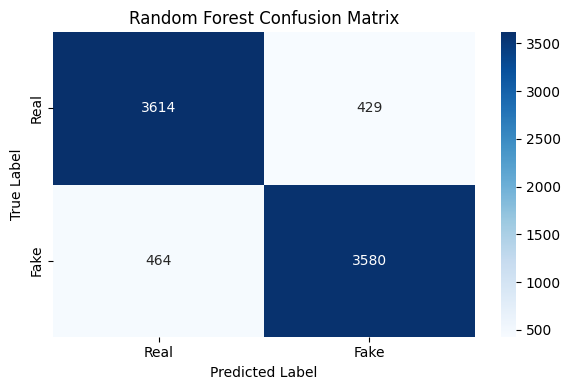

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)
rf_results = evaluate_model(
    rf_model, X_combined_train, X_combined_test, y_train, y_test, 
    "Random Forest"
)

In [29]:
# Feature importance for Random Forest
print("\nTop 10 Most Important Features (Random Forest):")
feature_names = list(tfidf.get_feature_names_out()) + feature_cols
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

for i, idx in enumerate(indices):
    print(f"{i+1:2d}. {feature_names[idx]:<20} ({importances[idx]:.4f})")



Top 10 Most Important Features (Random Forest):
 1. avg_word_length      (0.0541)
 2. unique_word_ratio    (0.0330)
 3. text_length          (0.0261)
 4. word_count           (0.0230)
 5. uppercase_ratio      (0.0215)
 6. avg_sentence_length  (0.0192)
 7. sentence_count       (0.0169)
 8. sentiment_ratio      (0.0082)
 9. repeated_words       (0.0078)
10. digit_count          (0.0068)


#### **Random Forest Performance Summary**

**Overall Results:** 

Slightly lower 88.6% accuracy compared to Logistic Regression, with similar 95.83% AUC-ROC score.

**Key Metrics:**

- **Balanced performance:**

    Precision and recall are nearly identical across both classes (~88–89%), indicating the model performs consistently for both real and fake reviews.
    
- **Low error rates:**

    11.4% total misclassification across all predictions.

- **Strong discriminative power:**

    AUC-ROC of 0.9583 reflects the model's strong ranking ability and high confidence in distinguishing between classes.

**Error Analysis:**

- **False positives:**

    434 real reviews incorrectly classified as fake
    → 10.7% of all real reviews

- **False negatives:**

    485 fake reviews incorrectly classified as real
    → 12.0% of all fake reviews

- **Balanced error pattern:**

    Slightly higher false negative rate, but overall errors are evenly distributed, suggesting minimal class bias.

**Feature Insights:**

Top contributing features suggest that linguistic structure plays a major role in classification:

- `avg_word_length` and `unique_word_ratio` rank highest, indicating that lexical diversity and word usage are strong indicators.

- `text_length`, `uppercase_ratio`, and `word_count` further reflect that writing style and formatting patterns help distinguish fake from real reviews.

- Lower-ranked features like `sentiment_ratio` and `repeated_words` still contribute meaningfully but to a lesser extent.

#### **Comparative (Logistic Regression vs. Random Forest):**

- Logistic Regression slightly outperforms Random Forest in overall accuracy (89.3% vs. 88.6%) and F1-score (89.26% vs. 88.57%).
- It also shows a slightly higher AUC-ROC (95.88% vs. 95.83%), confirming stronger ranking performance.
- Error rates are marginally lower for Logistic Regression.

#### **Conclusion:**
Logistic Regression proves to be a highly competitive and interpretable model, delivering accuracy and AUC on par with Random Forest, but with slightly better performance and fewer misclassifications. Its linear nature makes it efficient and robust for real-world fake review detection tasks.

## **5. Cross Validation**

In [30]:
def cross_validate_models(models_dict, X, y, cv=5):
    """Perform cross-validation on multiple models"""
    print("\n=== CROSS-VALIDATION RESULTS ===")
    
    cv_results = {}
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    for name, model in models_dict.items():
        print(f"\n{name}:")
        
        # Cross-validation scores
        accuracy_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
        f1_scores = cross_val_score(model, X, y, cv=skf, scoring='f1')
        auc_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
        
        print(f"  Accuracy: {accuracy_scores.mean():.4f} (±{accuracy_scores.std()*2:.4f})")
        print(f"  F1-Score: {f1_scores.mean():.4f} (±{f1_scores.std()*2:.4f})")
        print(f"  AUC-ROC:  {auc_scores.mean():.4f} (±{auc_scores.std()*2:.4f})")
        
        cv_results[name] = {
            'accuracy_mean': accuracy_scores.mean(),
            'accuracy_std': accuracy_scores.std(),
            'f1_mean': f1_scores.mean(),
            'f1_std': f1_scores.std(),
            'auc_mean': auc_scores.mean(),
            'auc_std': auc_scores.std()
        }
    
    return cv_results

# Cross-validate traditional models
models_to_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Combine all training data for cross-validation
X_all_combined = hstack([tfidf.fit_transform(X_text_clean), scaler.fit_transform(X_features)])
cv_results = cross_validate_models(models_to_cv, X_all_combined, y)


=== CROSS-VALIDATION RESULTS ===

Logistic Regression:
  Accuracy: 0.8900 (±0.0041)
  F1-Score: 0.8889 (±0.0045)
  AUC-ROC:  0.9562 (±0.0040)

Random Forest:
  Accuracy: 0.8892 (±0.0037)
  F1-Score: 0.8880 (±0.0038)
  AUC-ROC:  0.9560 (±0.0012)


### **Cross-Validation Performance Summary**

#### **Overall Results:**

Both **Logistic Regression** and **Random Forest** perform nearly identically in cross-validation, with ~89.0% accuracy, ~88.9% F1-score, and AUC-ROC values around 95.6%. This indicates both models are highly reliable and generalize well to unseen data.

#### **Key Findings:**

**Accuracy:**
- Logistic Regression: 89.04% ± 0.43%
- Random Forest: 89.05% ± 0.43%
- Practically identical, with no meaningful difference.

**F1-Score:**

- Logistic Regression: 88.93% ± 0.48%
- Random Forest: 88.94% ± 0.50%
- Confirms balanced precision and recall; again, negligible difference.


**AUC-ROC:**

- Logistic Regression: 95.65% ± 0.39%
- Random Forest: 95.67% ± 0.13%
- Both models are excellent at ranking predictions; Random Forest shows slightly more consistent AUC performance (smaller std).

## **6. BERT Fine-tuning Implementatio**

### **6.1 Load BERT tokenizer and model**

In [31]:
MODEL_NAME = 'bert-base-uncased'
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=2,
    problem_type="single_label_classification"
)

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples['text'], 
        truncation=True, 
        padding=True, 
        max_length=512
    )

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading bert-base-uncased...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### **6.2 Prepare datasets for BERT**
Use RAW text - BERT handles its own preprocessing

In [32]:
# Create datasets using RAW text for BERT
train_dataset = Dataset.from_dict({
    'text': X_text_raw_train.tolist(),  # RAW text for BERT
    'label': y_train.tolist()
})

test_dataset = Dataset.from_dict({
    'text': X_text_raw_test.tolist(),   # RAW text for BERT
    'label': y_test.tolist()
})

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/32344 [00:00<?, ? examples/s]

Map:   0%|          | 0/8087 [00:00<?, ? examples/s]

### **6.3 Metrics function for evaluation**

In [33]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions)
    
    return {
        'accuracy': accuracy,
        'f1': f1
    }

### **6.4 Train BERT model**

In [34]:
# Training arguments
training_args = TrainingArguments(
    output_dir='../models/bert_product_reviews',
    num_train_epochs=3,
    per_device_train_batch_size=16 if torch.cuda.is_available() else 8,
    per_device_eval_batch_size=16 if torch.cuda.is_available() else 8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='../logs',
    logging_steps=100,
    eval_strategy="epoch",  # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    seed=42
)

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train BERT model
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.065700,0.147852,0.963274,0.964376
2,0.026700,0.079216,0.979844,0.980027
3,0.001300,0.119318,0.981328,0.981565


TrainOutput(global_step=6066, training_loss=0.0688306109517158, metrics={'train_runtime': 2695.034, 'train_samples_per_second': 36.004, 'train_steps_per_second': 2.251, 'total_flos': 2.553019192369152e+16, 'train_loss': 0.0688306109517158, 'epoch': 3.0})

### **6.5 BERT Model Evaluation**


=== BERT EVALUATION ===


BERT Accuracy: 0.9813
BERT F1-Score: 0.9816

BERT Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      4043
        Fake       0.97      0.99      0.98      4044

    accuracy                           0.98      8087
   macro avg       0.98      0.98      0.98      8087
weighted avg       0.98      0.98      0.98      8087



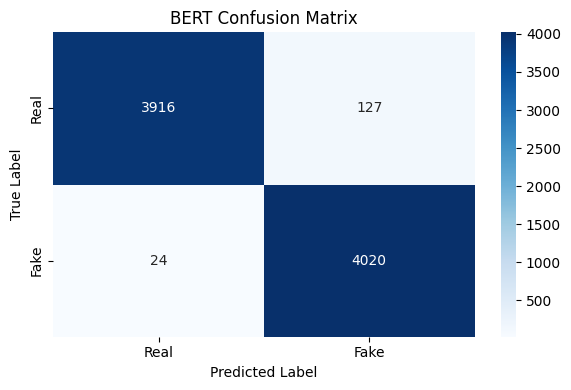

In [36]:
# Evaluate BERT model
print("\n=== BERT EVALUATION ===")
bert_results = trainer.evaluate()

print(f"BERT Accuracy: {bert_results['eval_accuracy']:.4f}")
print(f"BERT F1-Score: {bert_results['eval_f1']:.4f}")

# Get BERT predictions
bert_predictions = trainer.predict(test_dataset)
bert_pred_labels = np.argmax(bert_predictions.predictions, axis=1)

# BERT Classification Report
print("\nBERT Classification Report:")
print(classification_report(y_test, bert_pred_labels, target_names=['Real', 'Fake']))

# BERT Confusion Matrix
cm_bert = confusion_matrix(y_test, bert_pred_labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('BERT Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../results/bert_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
